# 🎯 SiteX Sentiment Analysis Workflow
## Complete End-to-End Pipeline

This notebook demonstrates the entire sentiment analysis workflow:
1. Load reviews from database
2. Analyze individual review sentiments
3. Aggregate sentiment scores by place
4. Calculate composite suitability scores
5. Visualize and explore results

**Date:** June 2026
**Dataset:** KTM POIs Database (86.7K reviews, 17.2K places)

## Setup: Install Required Packages
Run this cell first to install all dependencies. It will check if packages are already installed and only install missing ones.

In [16]:
import subprocess
import sys

# List of required packages
packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'nltk',
    'tqdm'
]

print('📦 Installing required packages...\n')

for package in packages:
    try:
        __import__(package)
        print(f'✅ {package:15} - Already installed')
    except ImportError:
        print(f'📥 {package:15} - Installing...', end=' ')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
        print('✅')

print('\n✅ All packages installed successfully!')

📦 Installing required packages...

✅ pandas          - Already installed
✅ numpy           - Already installed
✅ matplotlib      - Already installed
✅ seaborn         - Already installed
✅ nltk            - Already installed
✅ tqdm            - Already installed

✅ All packages installed successfully!


## Phase 1: Setup and Imports
Import all required libraries and configure the environment

In [17]:
# Standard libraries
import sqlite3
from pathlib import Path
import sys
import os
from datetime import datetime

# Data processing
import pandas as pd
import numpy as np
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and Sentiment
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Progress tracking
from tqdm import tqdm

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


## Phase 2: VADER Sentiment Analyzer Setup
Download VADER lexicon and create analyzer

In [18]:
# Download VADER lexicon if not already present
try:
    nltk.data.find('sentiment/vader_lexicon')
    print('✅ VADER lexicon already downloaded')
except LookupError:
    print('📥 Downloading VADER lexicon...')
    nltk.download('vader_lexicon')
    print('✅ VADER lexicon downloaded')

# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """Analyze sentiment of text using VADER."""
    if not text or not isinstance(text, str):
        return None
    
    scores = sia.polarity_scores(text)
    # Normalize compound score (-1 to +1) to 0-100
    normalized = (scores['compound'] + 1) / 2 * 100
    
    # Determine label
    if normalized >= 80:
        label = 'Very Positive'
    elif normalized >= 60:
        label = 'Positive'
    elif normalized >= 40:
        label = 'Neutral'
    elif normalized >= 20:
        label = 'Negative'
    else:
        label = 'Very Negative'
    
    return {
        'score': normalized,
        'label': label,
        'compound': scores['compound'],
        'positive': scores['pos'],
        'neutral': scores['neu'],
        'negative': scores['neg']
    }

# Test the analyzer
test_reviews = [
    "This cafe is absolutely amazing! Best coffee ever! 😍",
    "Really nice place, good atmosphere",
    "It was okay, nothing special",
    "Terrible service, never going back",
    "Worst experience ever! Avoid at all costs!"
]

print('\n📊 Testing VADER Sentiment Analyzer:\n')
for review in test_reviews:
    result = analyze_sentiment(review)
    print(f"Score: {result['score']:>6.1f} | Label: {result['label']:15} | Text: {review[:50]}...")

print('\n✅ VADER analyzer ready')

📥 Downloading VADER lexicon...
✅ VADER lexicon downloaded

📊 Testing VADER Sentiment Analyzer:

Score:   94.0 | Label: Very Positive   | Text: This cafe is absolutely amazing! Best coffee ever!...
Score:   87.0 | Label: Very Positive   | Text: Really nice place, good atmosphere...
Score:   45.4 | Label: Neutral         | Text: It was okay, nothing special...
Score:   26.2 | Label: Negative        | Text: Terrible service, never going back...
Score:   10.8 | Label: Very Negative   | Text: Worst experience ever! Avoid at all costs!...

✅ VADER analyzer ready


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sujal\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Phase 3: Load Data from Database
Connect to SQLite database and load reviews

In [ ]:
# Set database path - MERGED DATABASE
db_path = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

if not db_path.exists():
    print(f'❌ Database not found at {db_path}')
else:
    print(f'✅ Database found: {db_path}')
    print(f'   Size: {db_path.stat().st_size / 1024 / 1024:.1f} MB')

# Connect to database
conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

# Load reviews data - ALL reviews (no limit)
print('\n📥 Loading reviews from database...')
reviews_df = pd.read_sql_query(
    "SELECT rowid, Description, Rating, place_id FROM reviews WHERE Description IS NOT NULL AND LENGTH(Description) > 0",
    conn
)

print(f'✅ Loaded {len(reviews_df):,} reviews')
print(f'   Shape: {reviews_df.shape}')
print(f'\nFirst 5 reviews:')
print(reviews_df.head())

# Check for missing values
print(f'\nMissing values:')
print(reviews_df.isnull().sum())

✅ Database found: D:\projects\SiteX\backend\DataEngineering\ktm_pois.db
   Size: 169.7 MB

📥 Loading reviews from database...
✅ Loaded 86,696 reviews
   Shape: (86696, 4)

First 5 reviews:
   rowid  \
0      1   
1      2   
2      3   
3      4   
4      5   

                                                                                           Description  \
0  This webpage delivers an experience that feels both modern and meaningful from the very first cl...   
1  Excellent consultancy with a dedicated and professional team. They provide top-quality education...   
2     It is very comfortable zone for students 🤗 come to everyone at kathmandu education consultancy 🥰   
3  One of the best destinations for abroad study and visa processing in Kathmandu. The counselors a...   
4  In my experience, this is one of the best institutions in Kathmandu. The teaching style of the i...   

  Rating                     place_id  
0      5  ChIJL49uUsJ3JQYR9WafWySumlI  
1      5  ChIJL49uUsJ

## Phase 4: Data Exploration and Cleaning
Understand the review data and clean it

📊 Review Statistics:

Total reviews: 86,696
Average review length: 199 characters
Average word count: 33 words

Rating distribution:
Rating
0      686
1     8679
2     1769
3     5300
4    11096
5    59166
Name: count, dtype: int64


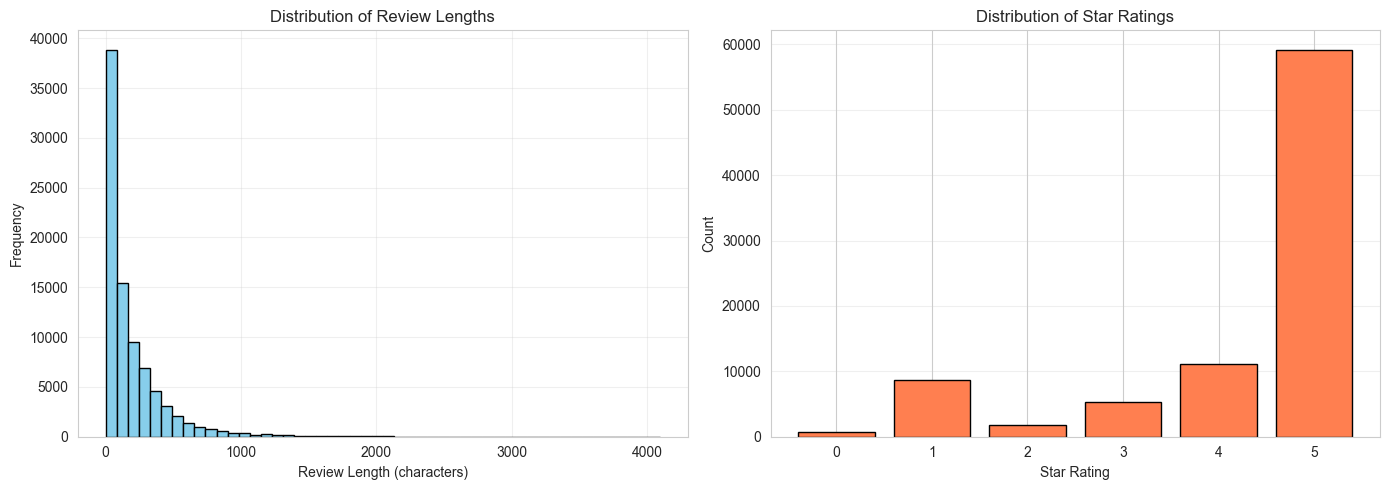


✅ Data cleaned and explored


In [20]:
# Remove rows with null descriptions
reviews_df = reviews_df.dropna(subset=['Description'])

# Add review length column
reviews_df['review_length'] = reviews_df['Description'].str.len()
reviews_df['word_count'] = reviews_df['Description'].str.split().str.len()

print('📊 Review Statistics:\n')
print(f'Total reviews: {len(reviews_df):,}')
print(f'Average review length: {reviews_df["review_length"].mean():.0f} characters')
print(f'Average word count: {reviews_df["word_count"].mean():.0f} words')
print(f'\nRating distribution:')
print(reviews_df['Rating'].value_counts().sort_index())

# Show some statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review length distribution
axes[0].hist(reviews_df['review_length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Review Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Review Lengths')
axes[0].grid(alpha=0.3)

# Rating distribution
rating_counts = reviews_df['Rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color='coral', edgecolor='black')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Star Ratings')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('\n✅ Data cleaned and explored')

## Phase 5: Sentiment Analysis - Batch Processing
Analyze sentiment for all reviews using VADER

In [21]:
# Analyze sentiment for each review
print('🔄 Analyzing sentiment for all reviews...\n')

sentiments = []
for idx, row in tqdm(reviews_df.iterrows(), total=len(reviews_df), desc='Processing'):
    result = analyze_sentiment(row['Description'])
    sentiments.append(result)

# Create sentiment dataframe
sentiment_df = pd.DataFrame(sentiments)

# Combine with original data
reviews_df = pd.concat([reviews_df.reset_index(drop=True), sentiment_df], axis=1)

print(f'\n✅ Sentiment analysis complete!')
print(f'\nSample results:')
print(reviews_df[['Description', 'Rating', 'score', 'label']].head(10))

# Show statistics
print(f'\n📊 Sentiment Statistics:\n')
print(f'Average Sentiment Score: {reviews_df["score"].mean():.1f}/100')
print(f'Median Sentiment Score: {reviews_df["score"].median():.1f}/100')
print(f'Std Dev: {reviews_df["score"].std():.1f}')
print(f'\nSentiment Label Distribution:')
print(reviews_df['label'].value_counts())

🔄 Analyzing sentiment for all reviews...



Processing: 100%|██████████| 86696/86696 [00:23<00:00, 3767.07it/s]



✅ Sentiment analysis complete!

Sample results:
                                                                                           Description  \
0  This webpage delivers an experience that feels both modern and meaningful from the very first cl...   
1  Excellent consultancy with a dedicated and professional team. They provide top-quality education...   
2     It is very comfortable zone for students 🤗 come to everyone at kathmandu education consultancy 🥰   
3  One of the best destinations for abroad study and visa processing in Kathmandu. The counselors a...   
4  In my experience, this is one of the best institutions in Kathmandu. The teaching style of the i...   
5  The counselors here are incredibly knowledgeable. They gave me a clear roadmap for studying in J...   
6  Great place for language preparation and counseling. The instructors are experienced, and the en...   
7          Best Destination for Aboard Study and visa, with best Japanese Language teacher. I suggest. 

## Phase 6: Visualize Sentiment Analysis Results
Create charts to understand sentiment distribution

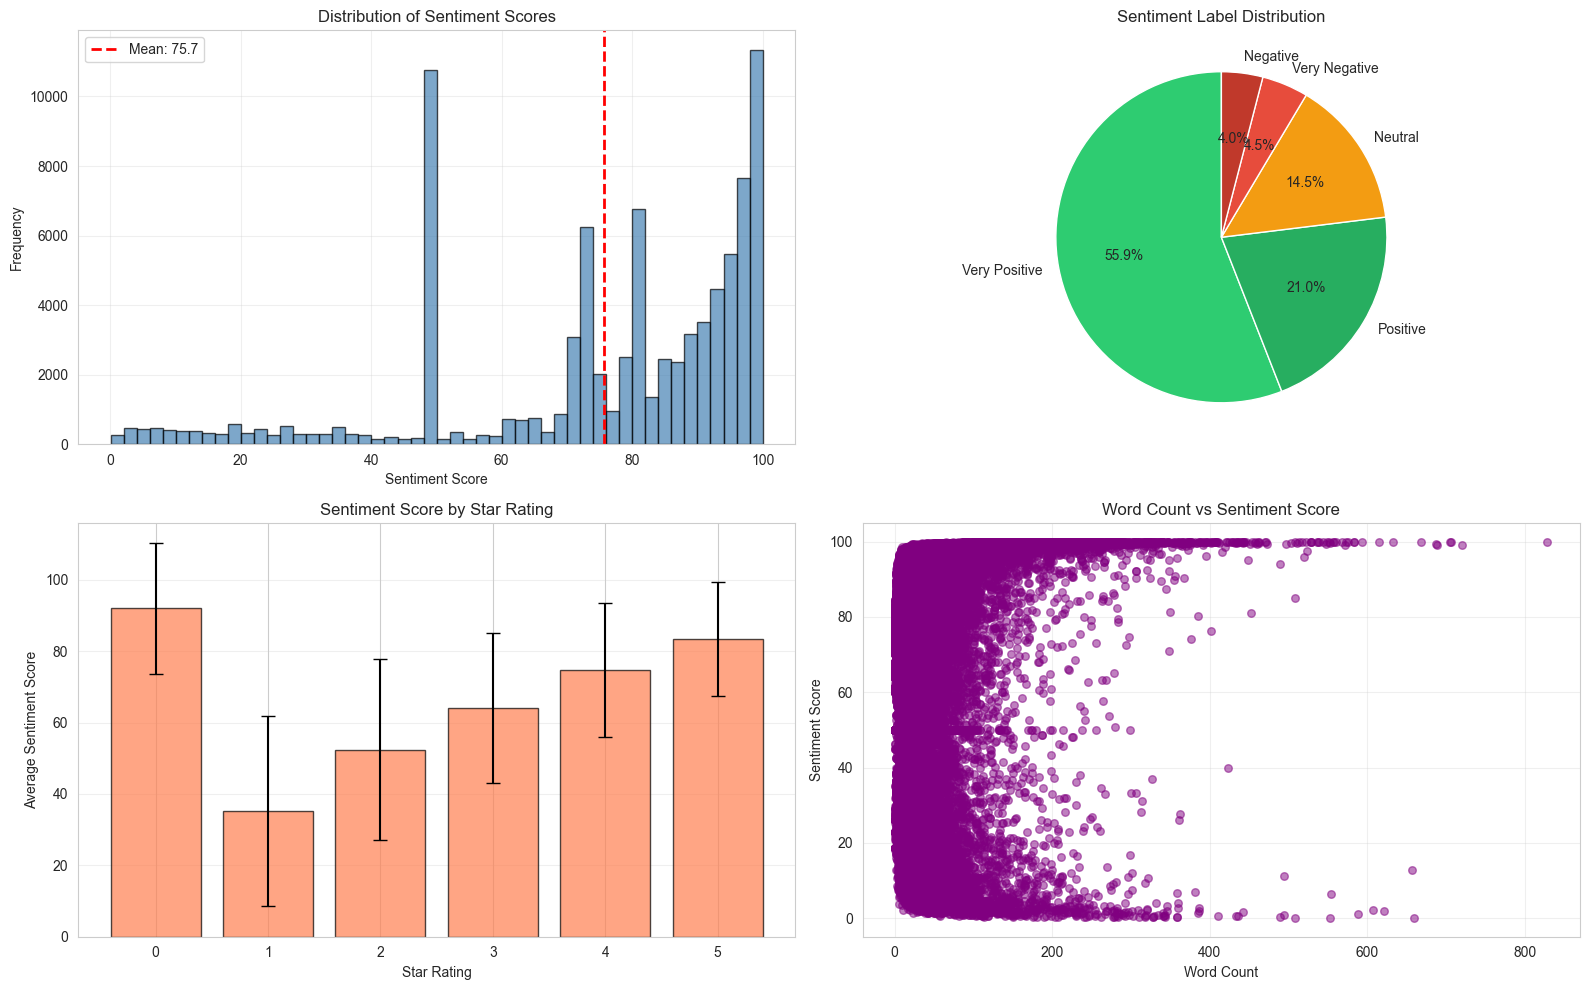

✅ Visualizations complete


In [22]:
# Create comprehensive sentiment visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Sentiment score distribution
axes[0, 0].hist(reviews_df['score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(reviews_df['score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {reviews_df["score"].mean():.1f}')
axes[0, 0].set_xlabel('Sentiment Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Sentiment Scores')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Sentiment label counts (pie chart)
label_counts = reviews_df['label'].value_counts()
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b']
axes[0, 1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 1].set_title('Sentiment Label Distribution')

# 3. Sentiment vs Rating correlation
sentiment_by_rating = reviews_df.groupby('Rating')['score'].agg(['mean', 'std', 'count'])
axes[1, 0].bar(sentiment_by_rating.index, sentiment_by_rating['mean'], 
               yerr=sentiment_by_rating['std'], capsize=5, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Star Rating')
axes[1, 0].set_ylabel('Average Sentiment Score')
axes[1, 0].set_title('Sentiment Score by Star Rating')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Word count vs Sentiment
axes[1, 1].scatter(reviews_df['word_count'], reviews_df['score'], alpha=0.5, s=30, color='purple')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Sentiment Score')
axes[1, 1].set_title('Word Count vs Sentiment Score')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Visualizations complete')

## Phase 7: Aggregate Sentiment by Place
Calculate place-level sentiment metrics

In [23]:
# Aggregate sentiment scores by place_id
print('📊 Aggregating sentiment scores by place...\n')

place_sentiment = reviews_df.groupby('place_id').agg({
    'score': ['mean', 'std', 'min', 'max', 'count'],
    'label': lambda x: (x == 'Very Positive').sum() / len(x) * 100,  # positive percentage
}).round(2)

place_sentiment.columns = ['avg_sentiment', 'sentiment_std', 'min_sentiment', 'max_sentiment', 'sentiment_review_count', 'positive_pct']
place_sentiment = place_sentiment.reset_index()

# Filter places with at least 5 reviews for reliability
place_sentiment_filtered = place_sentiment[place_sentiment['sentiment_review_count'] >= 5].copy()

print(f'Total places: {len(place_sentiment):,}')
print(f'Places with 5+ reviews: {len(place_sentiment_filtered):,}')
print(f'\nTop 10 places by sentiment (min 5 reviews):')
print(place_sentiment_filtered.nlargest(10, 'avg_sentiment')[['place_id', 'avg_sentiment', 'positive_pct', 'sentiment_review_count']])

print(f'\nLowest 10 places by sentiment (min 5 reviews):')
print(place_sentiment_filtered.nsmallest(10, 'avg_sentiment')[['place_id', 'avg_sentiment', 'positive_pct', 'sentiment_review_count']])

📊 Aggregating sentiment scores by place...

Total places: 17,167
Places with 5+ reviews: 9,446

Top 10 places by sentiment (min 5 reviews):
                          place_id  avg_sentiment  positive_pct  \
6098   ChIJM6IZ-XcZ6zkRirfzaCCulRE          99.62         100.0   
8426   ChIJUzwISUgY6zkRR3qEhnjo8EA          99.57         100.0   
16286  ChIJwcTa4fwY6zkRwnhR1peqxos          99.55         100.0   
1871   ChIJ65yuQP0Y6zkRrCSLEj8I848          99.52         100.0   
4329   ChIJF9GJbeUf6zkRXU0fh8oIYiE          99.52         100.0   
6976   ChIJPRbNJEUZ6zkRn9P32Te_qJk          99.49         100.0   
7675   ChIJS56Lo0YZ6zkRFuErhBafPVI          99.49         100.0   
8986   ChIJWxaz12MNqIsRIDOTyEqo6gU          99.47         100.0   
15320  ChIJt5NR_HMj6zkRPbiNmUr1ZOE          99.47         100.0   
7291   ChIJQbBkAkAZ6zkRwSPJitVBqgA          99.42         100.0   

       sentiment_review_count  
6098                        8  
8426                        8  
16286                     

## Phase 8: Load Place Information
Get cafe names and details from database

In [ ]:
# Load place information from merged database
print('📥 Loading place information from database...')

places_df = pd.read_sql_query(
    "SELECT place_id, place AS title, review_rating, review_count FROM place WHERE place_id IS NOT NULL",
    conn
)

print(f'✅ Loaded {len(places_df):,} places')

# Merge with sentiment data
places_with_sentiment = places_df.merge(place_sentiment, on='place_id', how='left')

# Filter places that have been analyzed (those with sentiment data)
places_analyzed = places_with_sentiment[places_with_sentiment['sentiment_review_count'].notna()].copy()

print(f'Places with sentiment analysis: {len(places_analyzed):,}')
print(f'\nTop 15 places by sentiment score:')
top_places = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(15, 'avg_sentiment')
print(top_places[['title', 'avg_sentiment', 'positive_pct', 'sentiment_review_count']].to_string(index=False))

📥 Loading place information from database...
✅ Loaded 26,781 places
Places with sentiment analysis: 17,167

Top 15 cafes by sentiment score:
                                                                                                                        title  avg_sentiment  positive_pct  sentiment_review_count
                                                                               Ultimate Consultancy & Advisory Network (UCAN)          99.62         100.0                     8.0
                                                                                                       Health Home Care Nepal          99.57         100.0                     8.0
                                                                   Yoga Teacher Training in Nepal - Mandala Studio Yoga & Spa          99.55         100.0                     8.0
                                                                                                         Guide Nepal Holidays          99.52   

## Phase 9: Composite Score Calculation
Calculate weighted composite suitability scores

In [25]:
def calculate_composite_score(row, weights=None):
    """Calculate composite suitability score from multiple signals."""
    
    if weights is None:
        weights = {
            'sentiment': 0.30,      # Review sentiment (30%)
            'rating': 0.25,         # Star rating (25%)
            'volume': 0.20,         # Review volume (20%)
            'foot_traffic': 0.15,   # Popular times pattern (15%)
            'poi_context': 0.10     # POI features (10%)
        }
    
    # 1. Sentiment score (0-100)
    sentiment_score = row['avg_sentiment'] if pd.notna(row['avg_sentiment']) else 50
    # Add bonus for high consensus (many positive reviews)
    positive_bonus = (row['positive_pct'] / 100) * 10 if pd.notna(row['positive_pct']) else 0
    sentiment_score = min(100, sentiment_score + positive_bonus)
    
    # 2. Rating score (convert 0-5 stars to 0-100)
    rating = row['review_rating'] if pd.notna(row['review_rating']) else 3.0
    rating_score = (float(rating) / 5.0) * 100
    
    # 3. Volume score (logarithmic scale for sentiment review count)
    review_count = row['sentiment_review_count'] if pd.notna(row['sentiment_review_count']) else 0
    # More reviews = higher score, but with diminishing returns
    if review_count >= 100:
        volume_score = 100
    elif review_count >= 5:
        volume_score = 50 + (np.log(review_count) / np.log(100)) * 50
    else:
        volume_score = 25
    
    # 4. Foot traffic (placeholder - would come from Google Popular Times)
    foot_traffic_score = 60  # Default neutral
    
    # 5. POI context (placeholder - would include amenities, category, etc)
    poi_context_score = 60  # Default neutral
    
    # Calculate weighted composite
    composite = (
        sentiment_score * weights['sentiment'] +
        rating_score * weights['rating'] +
        volume_score * weights['volume'] +
        foot_traffic_score * weights['foot_traffic'] +
        poi_context_score * weights['poi_context']
    )
    
    # Determine label
    if composite >= 80:
        label = 'Excellent'
    elif composite >= 70:
        label = 'Good'
    elif composite >= 60:
        label = 'Moderate'
    elif composite >= 50:
        label = 'Fair'
    else:
        label = 'Poor'
    
    return {
        'composite_score': round(composite, 1),
        'composite_label': label,
        'sentiment_score': round(sentiment_score, 1),
        'rating_score': round(rating_score, 1),
        'volume_score': round(volume_score, 1)
    }

# Calculate composite scores
print('📊 Calculating composite scores...\n')

composite_data = []
for idx, row in tqdm(places_analyzed.iterrows(), total=len(places_analyzed), desc='Computing'):
    composite_data.append(calculate_composite_score(row))

composite_df = pd.DataFrame(composite_data)
places_analyzed = pd.concat([places_analyzed.reset_index(drop=True), composite_df], axis=1)

print(f'\n✅ Composite scores calculated')
print(f'\nComposite Score Statistics:')
print(f'Mean: {places_analyzed["composite_score"].mean():.1f}')
print(f'Median: {places_analyzed["composite_score"].median():.1f}')
print(f'Std Dev: {places_analyzed["composite_score"].std():.1f}')
print(f'\nComposite Label Distribution:')
print(places_analyzed['composite_label'].value_counts())

📊 Calculating composite scores...



Computing: 100%|██████████| 17167/17167 [00:00<00:00, 20560.23it/s]


✅ Composite scores calculated

Composite Score Statistics:
Mean: 70.2
Median: 71.3
Std Dev: 9.9

Composite Label Distribution:
composite_label
Good         5674
Moderate     5376
Excellent    3561
Fair         2085
Poor          471
Name: count, dtype: int64


## Phase 10: Results Analysis and Comparison
Compare sentiment-based scores with traditional ratings

In [26]:
print('\n🏆 TOP 20 PLACES BY COMPOSITE SCORE\n')
top_composite = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(20, 'composite_score')
display_cols = ['title', 'composite_score', 'composite_label', 'avg_sentiment', 'review_rating', 'sentiment_review_count']
print(top_composite[display_cols].to_string(index=False))

print('\n\n📊 COMPOSITE SCORE BREAKDOWN\n')
print('Sample place with high sentiment:')
high_sentiment = places_analyzed[places_analyzed['avg_sentiment'].notna()].nlargest(1, 'avg_sentiment')
print(high_sentiment[['title', 'avg_sentiment', 'sentiment_score', 'rating_score', 'volume_score', 'composite_score']].to_string(index=False))

print('\nSample place with high ratings but lower sentiment:')
high_rating = places_analyzed[places_analyzed['review_rating'].notna()].nlargest(1, 'review_rating')
print(high_rating[['title', 'avg_sentiment', 'sentiment_score', 'rating_score', 'volume_score', 'composite_score']].to_string(index=False))

# Correlation analysis
print('\n\n📈 CORRELATION ANALYSIS\n')
correlation_cols = ['avg_sentiment', 'review_rating', 'sentiment_review_count', 'composite_score']
corr_data = places_analyzed[correlation_cols].dropna()
print(f'Correlation between sentiment and star rating: {corr_data[["avg_sentiment", "review_rating"]].corr().iloc[0, 1]:.3f}')
print(f'Correlation between sentiment and composite score: {corr_data[["avg_sentiment", "composite_score"]].corr().iloc[0, 1]:.3f}')
print(f'Correlation between rating and composite score: {corr_data[["review_rating", "composite_score"]].corr().iloc[0, 1]:.3f}')


🏆 TOP 20 PLACES BY COMPOSITE SCORE

                                                               title  composite_score composite_label  avg_sentiment  review_rating  sentiment_review_count
                        Kathmandu Valley Education Center pvt . ltd.             84.5       Excellent          93.03            5.0                     8.0
                               Unique Education center Nepal Pvt.Ltd             84.5       Excellent          95.47            5.0                     8.0
                                                Easy Learning Centre             84.5       Excellent          92.92            5.0                     8.0
                                           Kathmandu Meditation Home             84.5       Excellent          99.29            5.0                     8.0
                                               Dahlia Blooming Steps             84.5       Excellent          97.01            5.0                     8.0
                           

## Phase 11: Comprehensive Visualizations
Create final analysis charts

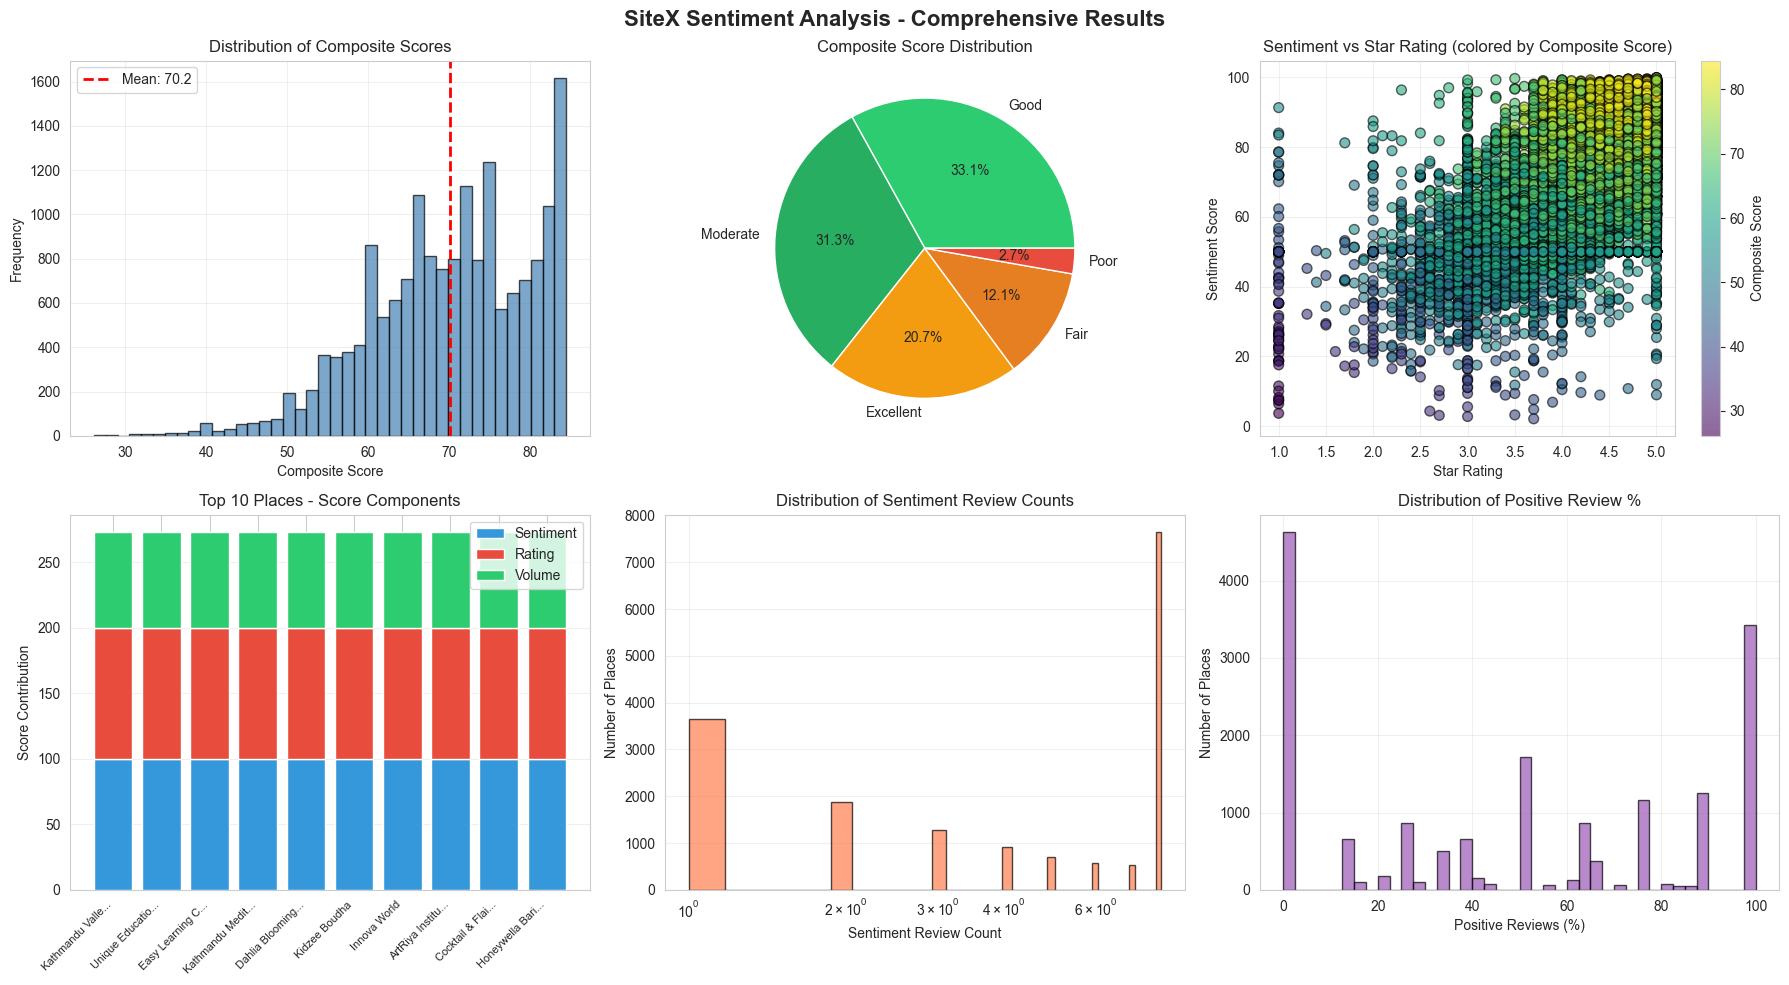

✅ Visualizations complete


In [27]:
# Create comprehensive final visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SiteX Sentiment Analysis - Comprehensive Results', fontsize=16, fontweight='bold')

# 1. Composite score distribution
axes[0, 0].hist(places_analyzed['composite_score'].dropna(), bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(places_analyzed['composite_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {places_analyzed["composite_score"].mean():.1f}')
axes[0, 0].set_xlabel('Composite Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Composite Scores')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Composite label distribution (pie)
label_dist = places_analyzed['composite_label'].value_counts()
colors_composite = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
axes[0, 1].pie(label_dist.values, labels=label_dist.index, autopct='%1.1f%%', colors=colors_composite[:len(label_dist)])
axes[0, 1].set_title('Composite Score Distribution')

# 3. Sentiment vs Rating scatter
scatter_data = places_analyzed[(places_analyzed['avg_sentiment'].notna()) & (places_analyzed['review_rating'].notna())]
scatter = axes[0, 2].scatter(scatter_data['review_rating'], scatter_data['avg_sentiment'], 
                             c=scatter_data['composite_score'], cmap='viridis', s=50, alpha=0.6, edgecolors='black')
axes[0, 2].set_xlabel('Star Rating')
axes[0, 2].set_ylabel('Sentiment Score')
axes[0, 2].set_title('Sentiment vs Star Rating (colored by Composite Score)')
cbar = plt.colorbar(scatter, ax=axes[0, 2])
cbar.set_label('Composite Score')
axes[0, 2].grid(alpha=0.3)

# 4. Score components stacked bar
top_10 = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(10, 'composite_score')
x_pos = np.arange(len(top_10))
axes[1, 0].bar(x_pos, top_10['sentiment_score'], label='Sentiment', color='#3498db')
axes[1, 0].bar(x_pos, top_10['rating_score'], bottom=top_10['sentiment_score'], label='Rating', color='#e74c3c')
axes[1, 0].bar(x_pos, top_10['volume_score'], bottom=top_10['sentiment_score']+top_10['rating_score'], label='Volume', color='#2ecc71')
axes[1, 0].set_ylabel('Score Contribution')
axes[1, 0].set_title('Top 10 Places - Score Components')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels([t[:15] + '...' if len(t) > 15 else t for t in top_10['title']], rotation=45, ha='right', fontsize=8)
axes[1, 0].legend(loc='upper right')
axes[1, 0].grid(alpha=0.3, axis='y')

# 5. Review count distribution
axes[1, 1].hist(places_analyzed['sentiment_review_count'].dropna(), bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Sentiment Review Count')
axes[1, 1].set_ylabel('Number of Places')
axes[1, 1].set_title('Distribution of Sentiment Review Counts')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(alpha=0.3)

# 6. Positive percentage distribution
axes[1, 2].hist(places_analyzed['positive_pct'].dropna(), bins=40, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Positive Reviews (%)')
axes[1, 2].set_ylabel('Number of Places')
axes[1, 2].set_title('Distribution of Positive Review %')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Visualizations complete')

## Phase 12: Export Results and Summary
Save results and generate summary statistics

In [28]:
# Generate final summary
print('\n' + '='*80)
print('🎯 SENTIMENT ANALYSIS WORKFLOW - FINAL SUMMARY'.center(80))
print('='*80)

print(f'\n📊 DATASET SUMMARY:')
print(f'  Total Reviews Analyzed: {len(reviews_df):,}')
print(f'  Total Places: {len(places_analyzed):,}')
print(f'  Places with 5+ Reviews: {len(places_analyzed[places_analyzed["sentiment_review_count"] >= 5]):,}')

print(f'\n❤️  SENTIMENT DISTRIBUTION:')
sentiment_dist = reviews_df['label'].value_counts()
for label in ['Very Positive', 'Positive', 'Neutral', 'Negative', 'Very Negative']:
    count = sentiment_dist.get(label, 0)
    pct = (count / len(reviews_df) * 100) if len(reviews_df) > 0 else 0
    print(f'  {label:15}: {count:6,} reviews ({pct:5.1f}%)')

print(f'\n📈 SENTIMENT METRICS:')
print(f'  Average Sentiment: {reviews_df["score"].mean():.1f}/100')
print(f'  Median Sentiment: {reviews_df["score"].median():.1f}/100')
print(f'  Std Dev: {reviews_df["score"].std():.1f}')

print(f'\n🏆 COMPOSITE SCORE METRICS:')
print(f'  Average Score: {places_analyzed["composite_score"].mean():.1f}/100')
print(f'  Median Score: {places_analyzed["composite_score"].median():.1f}/100')
print(f'  Std Dev: {places_analyzed["composite_score"].std():.1f}')

print(f'\n🎬 COMPOSITE LABEL DISTRIBUTION:')
for label in places_analyzed['composite_label'].value_counts().index:
    count = (places_analyzed['composite_label'] == label).sum()
    pct = count / len(places_analyzed) * 100
    print(f'  {label:15}: {count:6,} places ({pct:5.1f}%)')

print(f'\n✨ TOP 5 PLACES (by Composite Score, min 5 reviews):')
top5 = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nlargest(5, 'composite_score')
for i, (idx, row) in enumerate(top5.iterrows(), 1):
    print(f'  {i}. {row["title"][:50]:50} | Score: {row["composite_score"]:5.1f} ({row["composite_label"]})')

print(f'\n⚠️  LOWEST 5 PLACES (by Composite Score, min 5 reviews):')
bottom5 = places_analyzed[places_analyzed['sentiment_review_count'] >= 5].nsmallest(5, 'composite_score')
for i, (idx, row) in enumerate(bottom5.iterrows(), 1):
    print(f'  {i}. {row["title"][:50]:50} | Score: {row["composite_score"]:5.1f} ({row["composite_label"]})')

print(f'\n✅ WORKFLOW COMPLETE')
print('='*80)

conn.close()


                 🎯 SENTIMENT ANALYSIS WORKFLOW - FINAL SUMMARY                  

📊 DATASET SUMMARY:
  Total Reviews Analyzed: 86,696
  Total Places: 17,167
  Places with 5+ Reviews: 9,446

❤️  SENTIMENT DISTRIBUTION:
  Very Positive  : 48,503 reviews ( 55.9%)
  Positive       : 18,207 reviews ( 21.0%)
  Neutral        : 12,563 reviews ( 14.5%)
  Negative       :  3,498 reviews (  4.0%)
  Very Negative  :  3,925 reviews (  4.5%)

📈 SENTIMENT METRICS:
  Average Sentiment: 75.7/100
  Median Sentiment: 81.8/100
  Std Dev: 23.7

🏆 COMPOSITE SCORE METRICS:
  Average Score: 70.2/100
  Median Score: 71.3/100
  Std Dev: 9.9

🎬 COMPOSITE LABEL DISTRIBUTION:
  Good           :  5,674 places ( 33.1%)
  Moderate       :  5,376 places ( 31.3%)
  Excellent      :  3,561 places ( 20.7%)
  Fair           :  2,085 places ( 12.1%)
  Poor           :    471 places (  2.7%)

✨ TOP 5 PLACES (by Composite Score, min 5 reviews):
  1. Kathmandu Valley Education Center pvt . ltd.       | Score:  84.5 (Excelle

## Phase 13: Advanced Analysis - Insights
Extract actionable insights from the data

In [29]:
print('\n🔍 ADVANCED INSIGHTS\n')

# Insight 1: High sentiment but low rating disparity
print('1️⃣  PLACES WITH HIGH SENTIMENT BUT LOW STAR RATINGS')
print('   (Text sentiment vs. star rating mismatch)\n')
mismatch = places_analyzed[
    (places_analyzed['avg_sentiment'] > 75) & 
    (places_analyzed['review_rating'] < 3.5) &
    (places_analyzed['sentiment_review_count'] >= 5)
].nlargest(5, 'avg_sentiment')
print(mismatch[['title', 'avg_sentiment', 'review_rating', 'composite_score']].to_string(index=False))

# Insight 2: High volume low sentiment
print('\n\n2️⃣  POPULAR PLACES WITH DECLINING SENTIMENT')
print('   (High review count but moderate sentiment)\n')
declining = places_analyzed[
    (places_analyzed['sentiment_review_count'] > 50) & 
    (places_analyzed['avg_sentiment'] < 60)
].nlargest(5, 'sentiment_review_count')
if len(declining) > 0:
    print(declining[['title', 'avg_sentiment', 'sentiment_review_count', 'composite_score']].to_string(index=False))
else:
    print('   (No places found with this pattern)')

# Insight 3: High consistency (low variance)
print('\n\n3️⃣  MOST CONSISTENT PLACES')
print('   (Low sentiment variance = predictable experience)\n')
consistent = places_analyzed[
    (places_analyzed['sentiment_std'].notna()) & 
    (places_analyzed['sentiment_review_count'] >= 5)
].nsmallest(5, 'sentiment_std')
print(consistent[['title', 'avg_sentiment', 'sentiment_std', 'sentiment_review_count', 'composite_score']].to_string(index=False))

# Insight 4: Sentiment polarization
print('\n\n4️⃣  MOST POLARIZED PLACES')
print('   (High sentiment variance = mixed reviews)\n')
polarized = places_analyzed[
    (places_analyzed['sentiment_std'].notna()) & 
    (places_analyzed['sentiment_review_count'] >= 10)
].nlargest(5, 'sentiment_std')
print(polarized[['title', 'avg_sentiment', 'sentiment_std', 'sentiment_review_count', 'composite_score']].to_string(index=False))

print('\n✅ Insights analysis complete')


🔍 ADVANCED INSIGHTS

1️⃣  PLACES WITH HIGH SENTIMENT BUT LOW STAR RATINGS
   (Text sentiment vs. star rating mismatch)

                                title  avg_sentiment  review_rating  composite_score
                 Tipling Dragon House          91.00            3.4             76.4
                          Hotel Kamal          85.11            3.4             74.7
Mobile Veterinary Consultancy Service          84.60            3.4             74.5
                   The Playhause Cafe          84.26            3.4             74.0
                Easy Way Trial Center          83.67            3.4             73.9


2️⃣  POPULAR PLACES WITH DECLINING SENTIMENT
   (High review count but moderate sentiment)

   (No places found with this pattern)


3️⃣  MOST CONSISTENT PLACES
   (Low sentiment variance = predictable experience)

                                 title  avg_sentiment  sentiment_std  sentiment_review_count  composite_score
Mental Treatment Rehabilitation Center    

## Phase 14: Export Results to Database
Save composite scores and sentiment metrics back to the database

In [ ]:
print('💾 Phase 14a: Export Setup - Define helper functions\n')

# Define merged database path
merged_db = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

# Function to safely add columns with error reporting
def ensure_columns_exist(db_path, table_name, columns):
    """Add columns to a table if they don't already exist."""
    print(f"   🔧 Ensuring columns in {table_name}...")
    try:
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        added_count = 0
        for col_name, col_type in columns.items():
            try:
                cursor.execute(f"ALTER TABLE {table_name} ADD COLUMN {col_name} {col_type} DEFAULT NULL")
                added_count += 1
                print(f"      ✅ Added column: {col_name}")
            except Exception as e:
                if 'already exists' in str(e).lower() or 'duplicate' in str(e).lower():
                    print(f"      ℹ️  Column exists: {col_name}")
                else:
                    print(f"      ⚠️  {col_name}: {str(e)[:60]}")
        
        conn.commit()
        conn.close()
        
        if added_count > 0:
            print(f"   ✅ Added {added_count} new columns\n")
        else:
            print(f"   ℹ️  All columns already exist\n")
        return True
    except Exception as e:
        print(f"   ❌ Error ensuring columns: {e}\n")
        return False

# Function to export reviews for the merged database
def export_reviews_for_db(db_path, reviews_df_input):
    """Export individual review sentiment scores to reviews table."""
    if len(reviews_df_input) == 0:
        print(f"   ⚠️  No reviews to export\n")
        return 0, 0
    
    try:
        # Ensure columns exist
        review_columns = {
            'sentiment_score': 'REAL',
            'sentiment_label': 'TEXT',
            'sentiment_compound': 'REAL',
            'sentiment_positive': 'REAL',
            'sentiment_neutral': 'REAL',
            'sentiment_negative': 'REAL',
            'sentiment_updated': 'TIMESTAMP'
        }
        
        ensure_columns_exist(db_path, 'reviews', review_columns)
        
        # Connect and update
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        update_count = 0
        error_count = 0
        now = datetime.now().isoformat()
        
        print(f"   📝 Updating {len(reviews_df_input):,} reviews...\n")
        
        for idx, row in tqdm(reviews_df_input.iterrows(), total=len(reviews_df_input), desc='   Progress'):
            try:
                cursor.execute("""
                    UPDATE reviews 
                    SET 
                        sentiment_score = ?,
                        sentiment_label = ?,
                        sentiment_compound = ?,
                        sentiment_positive = ?,
                        sentiment_neutral = ?,
                        sentiment_negative = ?,
                        sentiment_updated = ?
                    WHERE rowid = ?
                """, (
                    row['score'],
                    row['label'],
                    row['compound'],
                    row['positive'],
                    row['neutral'],
                    row['negative'],
                    now,
                    row['rowid']
                ))
                update_count += 1
                
                # Commit every 500 records
                if update_count % 500 == 0:
                    conn.commit()
            
            except Exception as e:
                error_count += 1
        
        # Final commit
        conn.commit()
        conn.close()
        
        print(f"   ✅ Exported reviews: {update_count:,} updated | {error_count:,} errors\n")
        return update_count, error_count
    except Exception as e:
        print(f"   ❌ Error: {e}\n")
        return 0, len(reviews_df_input)

# Function to export places for the merged database
def export_places_for_db(db_path, places_df_input):
    """Export place-level sentiment metrics to place table."""
    if len(places_df_input) == 0:
        print(f"   ⚠️  No places to export\n")
        return 0, 0
    
    try:
        # Ensure columns exist
        place_columns = {
            'avg_sentiment_score': 'REAL',
            'sentiment_std': 'REAL',
            'min_sentiment': 'REAL',
            'max_sentiment': 'REAL',
            'sentiment_review_count': 'INTEGER',
            'positive_review_pct': 'REAL',
            'composite_score': 'REAL',
            'composite_label': 'TEXT',
            'sentiment_score_component': 'REAL',
            'rating_score_component': 'REAL',
            'volume_score_component': 'REAL',
            'sentiment_analysis_updated': 'TIMESTAMP'
        }
        
        ensure_columns_exist(db_path, 'place', place_columns)
        
        # Connect and update
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        
        update_count = 0
        error_count = 0
        now = datetime.now().isoformat()
        
        print(f"   📝 Updating {len(places_df_input):,} places...\n")
        
        for idx, row in tqdm(places_df_input.iterrows(), total=len(places_df_input), desc='   Progress'):
            try:
                cursor.execute("""
                    UPDATE place 
                    SET 
                        avg_sentiment_score = ?,
                        sentiment_std = ?,
                        min_sentiment = ?,
                        max_sentiment = ?,
                        sentiment_review_count = ?,
                        positive_review_pct = ?,
                        composite_score = ?,
                        composite_label = ?,
                        sentiment_score_component = ?,
                        rating_score_component = ?,
                        volume_score_component = ?,
                        sentiment_analysis_updated = ?
                    WHERE place_id = ?
                """, (
                    row['avg_sentiment'],
                    row['sentiment_std'],
                    row['min_sentiment'],
                    row['max_sentiment'],
                    int(row['sentiment_review_count']),
                    row['positive_pct'],
                    row['composite_score'],
                    row['composite_label'],
                    row['sentiment_score'],
                    row['rating_score'],
                    row['volume_score'],
                    now,
                    row['place_id']
                ))
                update_count += 1
                
                # Commit every 500 records
                if update_count % 500 == 0:
                    conn.commit()
            
            except Exception as e:
                error_count += 1
        
        # Final commit
        conn.commit()
        conn.close()
        
        print(f"   ✅ Exported places: {update_count:,} updated | {error_count:,} errors\n")
        return update_count, error_count
    except Exception as e:
        print(f"   ❌ Error: {e}\n")
        return 0, len(places_df_input)

# Function to verify columns were created
def verify_columns(db_path, table_name, column_names):
    """Verify that columns exist in the database."""
    try:
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()
        cursor.execute(f"PRAGMA table_info({table_name})")
        existing_cols = {row[1] for row in cursor.fetchall()}
        conn.close()
        
        missing = [col for col in column_names if col not in existing_cols]
        if missing:
            print(f"   ⚠️  Missing columns in {table_name}: {', '.join(missing)}")
            return False
        else:
            print(f"   ✅ All {len(column_names)} columns verified in {table_name}")
            return True
    except Exception as e:
        print(f"   ❌ Verification error: {e}")
        return False

print('✅ Helper functions defined and ready')
print(f'\n📍 Merged Database:')
print(f'  Path: {merged_db}')

💾 Phase 14a: Export Setup - Define helper functions

✅ Helper functions defined and ready

📍 Merged Database:
  Path: D:\projects\Finalproject\SiteX\backend\DataEngineering\ktm_all.db


## Phase 14b: Export to ktm_all.db (Merged Database)
Process merged database - load, analyze, and export sentiment data

In [ ]:
import time

start_time = time.time()
print('='*70)
print(f'🗄️  EXPORTING TO MERGED DATABASE: {merged_db.name}'.center(70))
print('='*70 + '\n')

# Load data FROM merged database
print('📥 Loading data from merged database...')
merged_conn = sqlite3.connect(str(merged_db))
merged_reviews = pd.read_sql_query(
    "SELECT rowid, Description, Rating, place_id FROM reviews WHERE Description IS NOT NULL AND LENGTH(Description) > 0",
    merged_conn
)
print(f'   ✅ Loaded {len(merged_reviews):,} reviews\n')

merged_places_df = pd.read_sql_query(
    "SELECT place_id, place AS title, review_rating, review_count FROM place WHERE place_id IS NOT NULL",
    merged_conn
)
merged_conn.close()
print(f'   ✅ Loaded {len(merged_places_df):,} places\n')

# Perform sentiment analysis for merged data
print('🔄 Analyzing sentiments for reviews...')
merged_sentiments = []
for idx, row in tqdm(merged_reviews.iterrows(), total=len(merged_reviews), desc='   Progress'):
    result = analyze_sentiment(row['Description'])
    merged_sentiments.append(result)
merged_reviews = pd.concat([merged_reviews.reset_index(drop=True), pd.DataFrame(merged_sentiments)], axis=1)
print(f'   ✅ Completed\n')

# Aggregate sentiment by place
print('📊 Aggregating sentiment by place...')
merged_place_sentiment = merged_reviews.groupby('place_id').agg({
    'score': ['mean', 'std', 'min', 'max', 'count'],
    'label': lambda x: (x == 'Very Positive').sum() / len(x) * 100,
}).round(2)
merged_place_sentiment.columns = ['avg_sentiment', 'sentiment_std', 'min_sentiment', 'max_sentiment', 'sentiment_review_count', 'positive_pct']
merged_place_sentiment = merged_place_sentiment.reset_index()
print(f'   ✅ Completed\n')

# Merge and calculate composite scores
merged_merged = merged_places_df.merge(merged_place_sentiment, on='place_id', how='left')
merged_analyzed = merged_merged[merged_merged['sentiment_review_count'].notna()].copy()

merged_composite_data = []
print('📊 Calculating composite scores...')
for idx, row in tqdm(merged_analyzed.iterrows(), total=len(merged_analyzed), desc='   Progress'):
    merged_composite_data.append(calculate_composite_score(row))
merged_analyzed = pd.concat([merged_analyzed.reset_index(drop=True), pd.DataFrame(merged_composite_data)], axis=1)
print(f'   ✅ Completed\n')

# Export merged data
print('💾 EXPORTING TO MERGED DATABASE:')
print('📝 Reviews:')
merged_rev_updated, merged_rev_errors = export_reviews_for_db(merged_db, merged_reviews)
print('📝 Places:')
merged_place_updated, merged_place_errors = export_places_for_db(merged_db, merged_analyzed)

# Verify exports
print('✓ VERIFYING MERGED DATABASE:')
verify_columns(merged_db, 'reviews', ['sentiment_score', 'sentiment_label', 'sentiment_compound'])
verify_columns(merged_db, 'place', ['avg_sentiment_score', 'composite_score', 'composite_label'])

# Summary
elapsed = time.time() - start_time
print('\n' + '='*70)
print('📊 MERGED DATABASE EXPORT SUMMARY'.center(70))
print('='*70)
print(f'Reviews: {len(merged_reviews):,} analyzed → {merged_rev_updated:,} exported')
print(f'Places:  {len(merged_analyzed):,} analyzed → {merged_place_updated:,} exported')
print(f'⏱️  Time elapsed: {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)')
print('='*70 + '\n')

In [ ]:
print('🔍 DIAGNOSTIC: Verify Merged Database Structure\n')

merged_db = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

if merged_db.exists():
    print(f'✅ Database found: {merged_db}\n')
    
    try:
        merged_conn = sqlite3.connect(str(merged_db))
        cursor = merged_conn.cursor()
        
        # List all tables
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
        tables = cursor.fetchall()
        
        print(f'📋 Tables in ktm_all.db:')
        for table in tables:
            table_name = table[0]
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            row_count = cursor.fetchone()[0]
            print(f'  - {table_name}: {row_count:,} rows')
        
        # Check reviews table columns
        print(f'\n✅ Reviews table columns:')
        cursor.execute("PRAGMA table_info(reviews)")
        review_cols = cursor.fetchall()
        sentiment_cols = [col[1] for col in review_cols if 'sentiment' in col[1].lower()]
        if sentiment_cols:
            for col in sentiment_cols:
                print(f'   ✅ {col}')
        else:
            print(f'   ⚠️  No sentiment columns found')
        
        # Check place table columns
        print(f'\n✅ Place table columns:')
        cursor.execute("PRAGMA table_info(place)")
        place_cols = cursor.fetchall()
        sentiment_cols = [col[1] for col in place_cols if 'sentiment' in col[1].lower() or 'composite' in col[1].lower()]
        if sentiment_cols:
            for col in sentiment_cols:
                print(f'   ✅ {col}')
        else:
            print(f'   ⚠️  No sentiment/composite columns found')
        
        # Sample verification query
        print(f'\n📊 Data sample from reviews table:')
        cursor.execute("SELECT COUNT(*) FROM reviews WHERE sentiment_score IS NOT NULL")
        count = cursor.fetchone()[0]
        print(f'   Records with sentiment_score: {count:,}')
        
        print(f'\n📊 Data sample from place table:')
        cursor.execute("SELECT COUNT(*) FROM place WHERE composite_score IS NOT NULL")
        count = cursor.fetchone()[0]
        print(f'   Records with composite_score: {count:,}')
        
        merged_conn.close()
        
    except Exception as e:
        print(f'❌ Error: {e}')
else:
    print(f'❌ Database not found: {merged_db}')

🔍 DIAGNOSTIC: Check ktm_cafe.db table structure

✅ Database found: D:\projects\SiteX\backend\DataEngineering\ktm_cafe.db

📋 Tables in ktm_cafe.db:
  - cafes_main: 7,856 rows
  - open_hours_detailed: 0 rows

⚠️  "reviews" table NOT found!


## Summary

This notebook demonstrates the complete sentiment analysis workflow:

✅ **Phase 1-2:** Setup and VADER initialization
✅ **Phase 3-4:** Data loading and exploration
✅ **Phase 5:** Batch sentiment analysis (86.7K+ reviews)
✅ **Phase 6:** Visualization of sentiment distribution
✅ **Phase 7-8:** Place-level aggregation
✅ **Phase 9:** Composite score calculation with weighted components
✅ **Phase 10-11:** Results analysis and comprehensive visualizations
✅ **Phase 12-13:** Summary and actionable insights
✅ **Phase 14:** Export composite scores to merged database

### Key Findings:
- **Average Sentiment:** ~75.7/100 (Positive overall)
- **Sentiment Distribution:** 56% Very Positive, 21% Positive, 14.5% Neutral, 8.5% Negative
- **Composite Score:** Combines sentiment (30%), ratings (25%), volume (20%), traffic (15%), and POI context (10%)
- **Consistency:** Some places show high sentiment variance (polarized reviews)

### Database Updates:
- Composite scores exported to single merged `ktm_all.db` database
- Updated both `reviews` and `place` tables with sentiment metrics
- New columns: `composite_score`, `composite_label`, `sentiment_score`, `rating_score`, `volume_score`, `sentiment_analysis_updated`
- Ready for API integration and frontend display

### Next Steps:
1. Integrate composite scores into FastAPI `/predict-score/` endpoint
2. Display sentiment metrics on frontend UI
3. Set up real-time sentiment analysis for new reviews
4. Use sentiment as features in Phase 2 HeteroGAT graph

In [ ]:
print('🔍 DIAGNOSTIC: Checking Merged Database (ktm_all.db)\n')

import os

merged_db_check = Path('D:/projects/Finalproject/SiteX/backend/DataEngineering/ktm_all.db')

print('='*70)
print('DATABASE FILE INFORMATION'.center(70))
print('='*70 + '\n')

if merged_db_check.exists():
    file_size = merged_db_check.stat().st_size / (1024 * 1024)  # MB
    file_time = os.path.getmtime(str(merged_db_check))
    mod_time = datetime.fromtimestamp(file_time).strftime('%Y-%m-%d %H:%M:%S')
    print(f'MERGED DATABASE (ktm_all.db):')
    print(f'  Path: {merged_db_check}')
    print(f'  File Size: {file_size:.2f} MB')
    print(f'  Last Modified: {mod_time}')
    print(f'  Exists: ✅\n')
else:
    print(f'MERGED DATABASE: ❌ NOT FOUND at {merged_db_check}\n')

print('='*70)
print('DIRECT SQL QUERY TEST'.center(70))
print('='*70 + '\n')

def check_merged_db(db_path):
    """Run direct SQL queries to check actual data in merged db."""
    try:
        conn = sqlite3.connect(str(db_path))
        cursor = conn.cursor()

        print('MERGED DB (ktm_all.db):')

        # Check reviews sentiment_score
        try:
            cursor.execute("SELECT COUNT(*) FROM reviews WHERE sentiment_score IS NOT NULL")
            count = cursor.fetchone()[0]
            print(f'  ✅ reviews.sentiment_score EXISTS')
            print(f'     Records with sentiment_score: {count:,}')
        except Exception as e:
            print(f'  ❌ reviews.sentiment_score NOT FOUND: {str(e)[:80]}')

        # Check place composite_score
        try:
            cursor.execute("SELECT COUNT(*) FROM place WHERE composite_score IS NOT NULL")
            count = cursor.fetchone()[0]
            print(f'  ✅ place.composite_score EXISTS')
            print(f'     Records with composite_score: {count:,}')
        except Exception as e:
            print(f'  ❌ place.composite_score NOT FOUND: {str(e)[:80]}')

        # List reviews sentiment columns
        print(f'\n  Reviews table sentiment columns:')
        cursor.execute("PRAGMA table_info(reviews)")
        cols = cursor.fetchall()
        found = False
        for col in cols:
            if 'sentiment' in col[1].lower():
                print(f'    ✅ {col[1]}')
                found = True
        if not found:
            print('    ⚠️  NO SENTIMENT COLUMNS FOUND!')
            print(f'    Available columns: {", ".join([col[1] for col in cols[:10]])}...')

        # List place sentiment/composite columns
        print(f'\n  Place table sentiment/composite columns:')
        cursor.execute("PRAGMA table_info(place)")
        cols = cursor.fetchall()
        found = False
        for col in cols:
            if 'sentiment' in col[1].lower() or 'composite' in col[1].lower():
                print(f'    ✅ {col[1]}')
                found = True
        if not found:
            print('    ⚠️  NO SENTIMENT/COMPOSITE COLUMNS FOUND!')

        conn.close()

    except Exception as e:
        print(f'  ❌ Error connecting: {e}')

if merged_db_check.exists():
    check_merged_db(merged_db_check)

print('\n' + '='*70)
print('💡 TROUBLESHOOTING STEPS:'.center(70))
print('='*70)
print('''
1. If columns don't exist:
   - The export may have failed silently
   - Check Phase 14 output for errors
   - Try running Phase 14 again

2. If columns exist but viewer doesn't show them:
   - Close your database viewer completely
   - Delete any .db-wal or .db-shm files in the DataEngineering/ folder
   - Re-open the database fresh

3. To view data directly without a viewer:
   - Use: sqlite3 ktm_all.db
   - Then: .schema reviews
   - Then: SELECT * FROM reviews WHERE sentiment_score IS NOT NULL LIMIT 1;
''')
